<a href="https://colab.research.google.com/github/shreya2k3/Clustering/blob/main/Clustering_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df = pd.read_csv(url, header=None)

# Assign column names manually (since the UCI version lacks them)
columns = ['ID', 'Diagnosis'] + [f'Feature_{i}' for i in range(1, 31)]
df.columns = columns

# Drop ID column as it's not useful for clustering
df.drop(columns=['ID'], inplace=True)

# Convert Diagnosis ('M' for malignant, 'B' for benign) to numerical (optional)
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Display first few rows
df.head(20)


,Diagnosis,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_21,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Feature_29,Feature_30
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678
5,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440
6,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368
7,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510
8,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720
9,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750


                           Calinski-Harabasz                     Davies-Bouldin               Silhouette              
Clusters                                   3         4         5              3      4      5          3      4      5
Algorithm    Preprocessing                                                                                            
Hierarchical none                   1089.929  1245.568  1541.859          0.631  0.609  0.611      0.508  0.509  0.511
             normalize               235.843   185.186   158.210          1.466  1.915  1.856      0.335  0.137  0.128
             pca                    1089.940  1369.419  1421.906          0.615  0.586  0.592      0.519  0.527  0.478
             transform               182.174   138.090   116.735          1.556  1.485  1.625      0.330  0.298  0.243
K-Means      none                   1246.261  1444.518  1609.690          0.633  0.606  0.616      0.647  0.544  0.507
             normalize               253.221   2

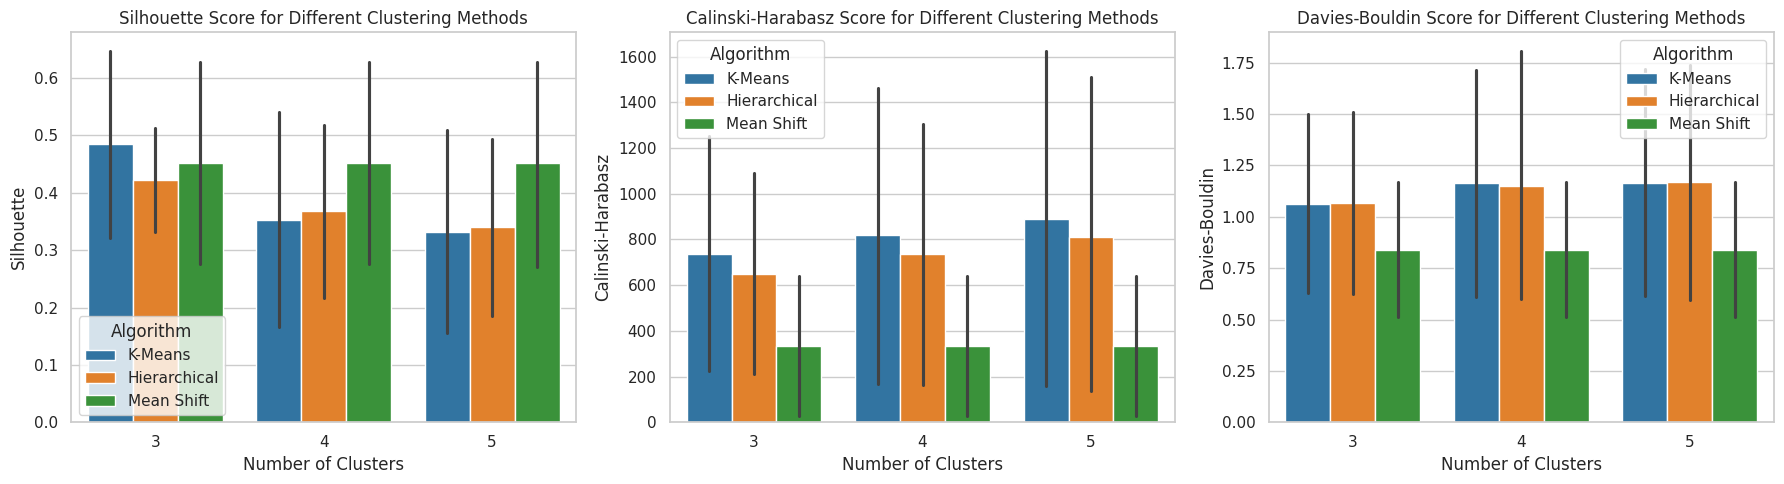

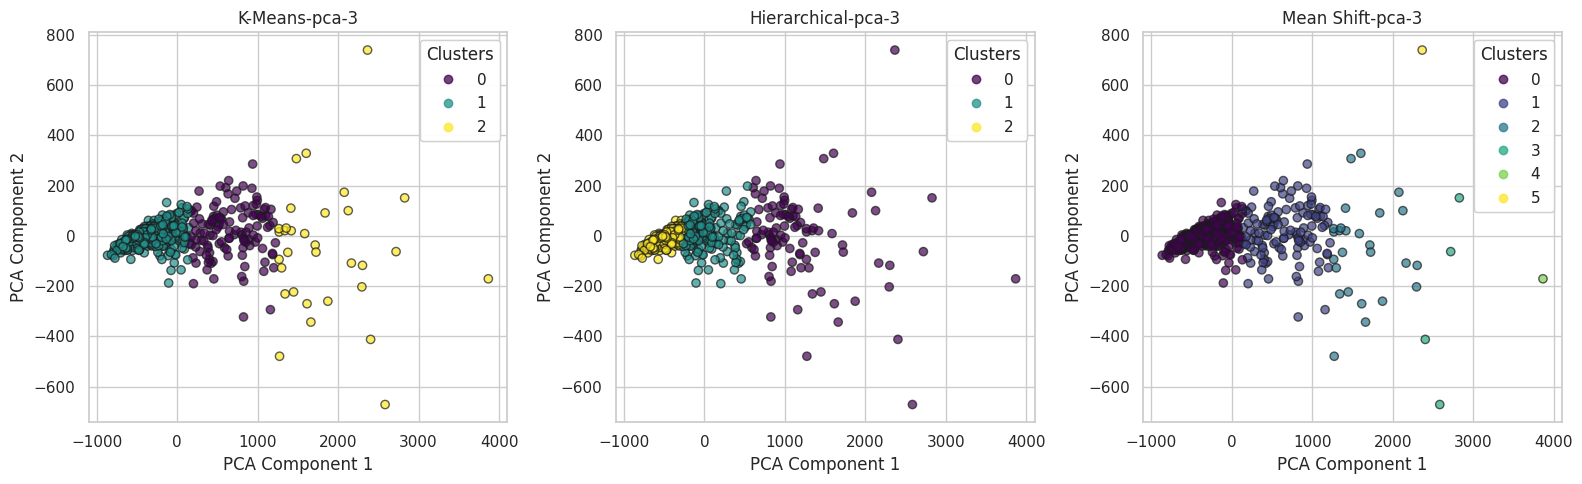

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, MeanShift
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Function to preprocess data
def preprocess_data(method, data):
    if method == 'normalize':
        return MinMaxScaler().fit_transform(data)
    elif method == 'transform':
        return StandardScaler().fit_transform(data)
    elif method == 'pca':
        return PCA(n_components=2).fit_transform(data)
    else:
        return data  # No processing

# Function to evaluate clustering performance
def evaluate_clustering(X, labels):
    return {
        'Silhouette': round(silhouette_score(X, labels), 3),
        'Calinski-Harabasz': round(calinski_harabasz_score(X, labels), 3),
        'Davies-Bouldin': round(davies_bouldin_score(X, labels), 3)
    }

# Run clustering experiments
def run_clustering_experiment():
    # Load dataset
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)

    # Define methods and clusters
    methods = ['none', 'normalize', 'transform', 'pca']
    clusters = [3, 4, 5]
    algorithms = {'K-Means': KMeans, 'Hierarchical': AgglomerativeClustering, 'Mean Shift': MeanShift}

    results = []
    all_cluster_labels = {}  # Store labels for visualization

    for method in methods:
        X_processed = preprocess_data(method, X)

        for c in clusters:
            for algo_name, algo in algorithms.items():
                if algo_name == "Mean Shift":
                    model = algo().fit(X_processed)  # Mean Shift does not take `n_clusters`
                else:
                    model = algo(n_clusters=c).fit(X_processed)

                scores = evaluate_clustering(X_processed, model.labels_)

                results.append({
                    'Algorithm': algo_name,
                    'Preprocessing': method,
                    'Clusters': c,
                    'Silhouette': scores['Silhouette'],
                    'Calinski-Harabasz': scores['Calinski-Harabasz'],
                    'Davies-Bouldin': scores['Davies-Bouldin']
                })

                # Store labels for PCA visualization
                if method == "pca" and c == 3:
                    all_cluster_labels[f"{algo_name}-{method}-{c}"] = (X_processed, model.labels_)

    # Convert results to a DataFrame
    df_results = pd.DataFrame(results)

    # Format as shown in your table
    df_table = df_results.pivot_table(
        index=['Algorithm', 'Preprocessing'],
        columns='Clusters',
        values=['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin']
    )

    # Print formatted table
    print(df_table.to_string())

    # Generate visualizations
    plot_results(df_results, all_cluster_labels)

    return df_table

# Function to generate visualizations
def plot_results(df, cluster_labels):
    sns.set(style="whitegrid")

    # Bar plots for scores
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, metric in enumerate(["Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]):
        sns.barplot(
            data=df,
            x="Clusters",
            y=metric,
            hue="Algorithm",
            ax=axes[i],
            palette="tab10"
        )
        axes[i].set_title(f"{metric} Score for Different Clustering Methods")
        axes[i].set_ylabel(metric)
        axes[i].set_xlabel("Number of Clusters")
        axes[i].legend(title="Algorithm")

    plt.tight_layout()
    plt.show()

    # PCA Scatter Plots for clustering visualization
    fig, axes = plt.subplots(1, len(cluster_labels), figsize=(16, 5))

    for i, (key, (X_pca, labels)) in enumerate(cluster_labels.items()):
        ax = axes[i]
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", edgecolor="k", alpha=0.7)
        ax.set_title(f"{key}")
        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
        ax.add_artist(legend1)

    plt.tight_layout()
    plt.show()

# Run the experiment
clustering_results = run_clustering_experiment()
